# Task 3.1 Unsupervised Learning - Clustering

by Sneha Sivakaran
Modul 12

# **Task 1** Load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Modul 12/food.csv', index_col=0)

print('Shape:', df.shape)
print('\nFirst 5 lines:')
df.head()

Shape: (25, 9)

First 5 lines:


,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0


In [2]:
# Key information about the dataset
print('Column names:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDescriptive statistics:')
df.describe()

Column names: ['RedMeat', 'WhiteMeat', 'Eggs', 'Milk', 'Fish', 'Cereals', 'Starch', 'Nuts', 'Fr.Veg']

Data types:
RedMeat      float64
WhiteMeat    float64
Eggs         float64
Milk         float64
Fish         float64
Cereals      float64
Starch       float64
Nuts         float64
Fr.Veg       float64
dtype: object

Missing values:
RedMeat      0
WhiteMeat    0
Eggs         0
Milk         0
Fish         0
Cereals      0
Starch       0
Nuts         0
Fr.Veg       0
dtype: int64

Descriptive statistics:


,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,9.828000,7.896000,2.936000,17.112000,4.284000,32.248000,4.276000,3.072000,4.136000
std,3.347078,3.694081,1.117617,7.105416,3.402533,10.974786,1.634085,1.985682,1.803903
min,4.400000,1.400000,0.500000,4.900000,0.200000,18.600000,0.600000,0.700000,1.400000
25%,7.800000,4.900000,2.700000,11.100000,2.100000,24.300000,3.100000,1.500000,2.900000
50%,9.500000,7.800000,2.900000,17.600000,3.400000,28.000000,4.700000,2.400000,3.800000
75%,10.600000,10.800000,3.700000,23.300000,5.800000,40.100000,5.700000,4.700000,4.900000
max,18.000000,14.000000,4.700000,33.700000,14.200000,56.700000,6.500000,7.800000,7.900000


# **Task 2** Data pre-processing – Z-transformation

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert to a DataFrame for better readability
df_scaled = pd.DataFrame(X_scaled, index=df.index, columns=df.columns)

print('Scaled data (Z-transformed):')
print(f'Median value (should be ~0): {df_scaled.mean().mean():.6f}')
print(f'Standard deviation (should be around 1): {df_scaled.std().mean():.6f}')
df_scaled.head()

Scaled data (Z-transformed):
Median value (should be ~0): -0.000000
Standard deviation (should be around 1): 1.020621


,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
Albania,0.082941,-1.794750,-2.224584,-1.179570,-1.225033,0.934804,-2.295965,1.247968,-1.378251
Austria,-0.282974,1.686446,1.245621,0.400468,-0.655111,-0.395051,-0.422218,-0.910790,0.092789
Belgium,1.119699,0.387905,1.062979,0.055732,0.064791,-0.525246,0.889405,-0.499598,-0.076947
Bulgaria,-0.618396,-0.523837,-1.220051,-1.265754,-0.925074,2.273959,-1.983674,0.322786,0.036210
Czechoslovakia,-0.039031,0.968104,-0.124197,-0.662467,-0.685107,0.190830,0.452198,-1.013588,-0.076947


# **Task 3** KMeans Clustering

In [4]:
from sklearn.cluster import KMeans
from sklearn import metrics

silhouette_scores = {}

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = metrics.silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f'k={k}  →  Silhouette coefficient: {score:.4f}')

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f'\n Best k = {best_k} with a silhouette score = {silhouette_scores[best_k]:.4f}')

k=2  →  Silhouette coefficient: 0.3271
k=3  →  Silhouette coefficient: 0.3352
k=4  →  Silhouette coefficient: 0.2544
k=5  →  Silhouette coefficient: 0.2639

 Best k = 3 with a silhouette score = 0.3352


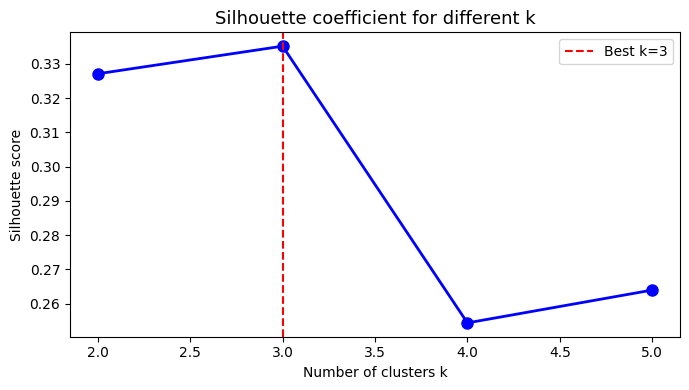


Cluster classification (k=3):
Cluster
0     4
1    15
2     6
Name: count, dtype: int64


In [6]:
# Visualising silhouette scores
plt.figure(figsize=(7, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()),
         marker='o', color='blue', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.title('Silhouette coefficient for different k', fontsize=13)
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette score')
plt.legend()
plt.tight_layout()
plt.show()

# Final k-means model with the optimal k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = cluster_labels
print(f'\nCluster classification (k={best_k}):')
print(df['Cluster'].value_counts().sort_index())

# **Task 4** Visualisation of K-means clustering using PCA

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f'Explained variance – PC1: {explained_var[0]:.2%}, PC2: {explained_var[1]:.2%}')
print(f'Total explained variance: {sum(explained_var):.2%}')

Explained variance – PC1: 44.52%, PC2: 18.17%
Total explained variance: 62.68%


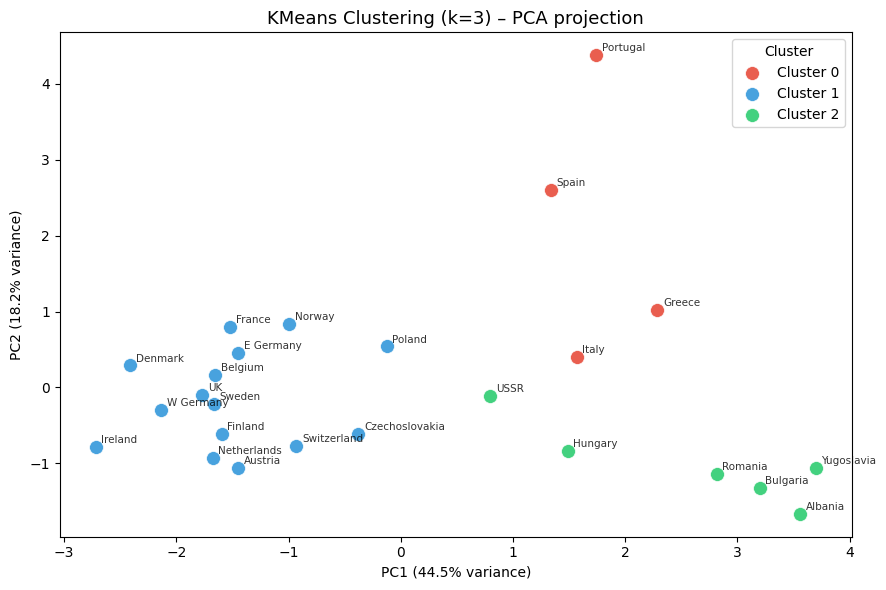

In [8]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 6))

for cluster_id in range(best_k):
    mask = cluster_labels == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cluster_id], label=f'Cluster {cluster_id}',
               s=100, edgecolors='white', linewidths=0.5, alpha=0.9)

# Label country names
for i, country in enumerate(df.index):
    ax.annotate(country, (X_pca[i, 0] + 0.05, X_pca[i, 1] + 0.05),
                fontsize=7.5, alpha=0.8)

ax.set_title(f'KMeans Clustering (k={best_k}) – PCA projection', fontsize=13)
ax.set_xlabel(f'PC1 ({explained_var[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({explained_var[1]:.1%} variance)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

# **Task 5** Hierarchical clustering





In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Calculate the linkage matrix (Ward’s method)
Z = linkage(X_scaled, method='ward')

print('Linkage matrix (first 5 entries):')
print(pd.DataFrame(Z[:5], columns=['Cluster 1', 'Cluster 2', 'Distance', 'Size']).round(3))

Linkage matrix (first 5 entries):
   Cluster 1  Cluster 2  Distance  Size
0       17.0       24.0     1.007   2.0
1        1.0       13.0     1.146   2.0
2        5.0       19.0     1.410   2.0
3        2.0       23.0     1.447   2.0
4       11.0       28.0     1.865   3.0


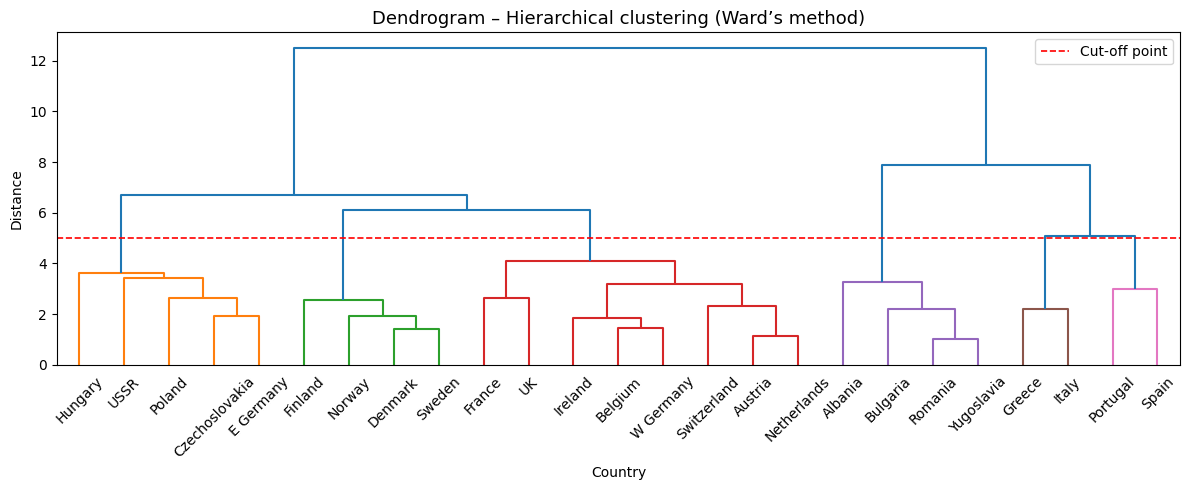

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

dendrogram(
    Z,
    labels=df.index.tolist(),
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=5.0,
    ax=ax
)

ax.set_title('Dendrogram – Hierarchical clustering (Ward’s method)', fontsize=13)
ax.set_xlabel('Country')
ax.set_ylabel('Distance')
ax.axhline(y=5.0, color='red', linestyle='--', linewidth=1.2, label='Cut-off point')
ax.legend()
plt.tight_layout()
plt.show()

# **Task 6** Heatmap mit Clustering

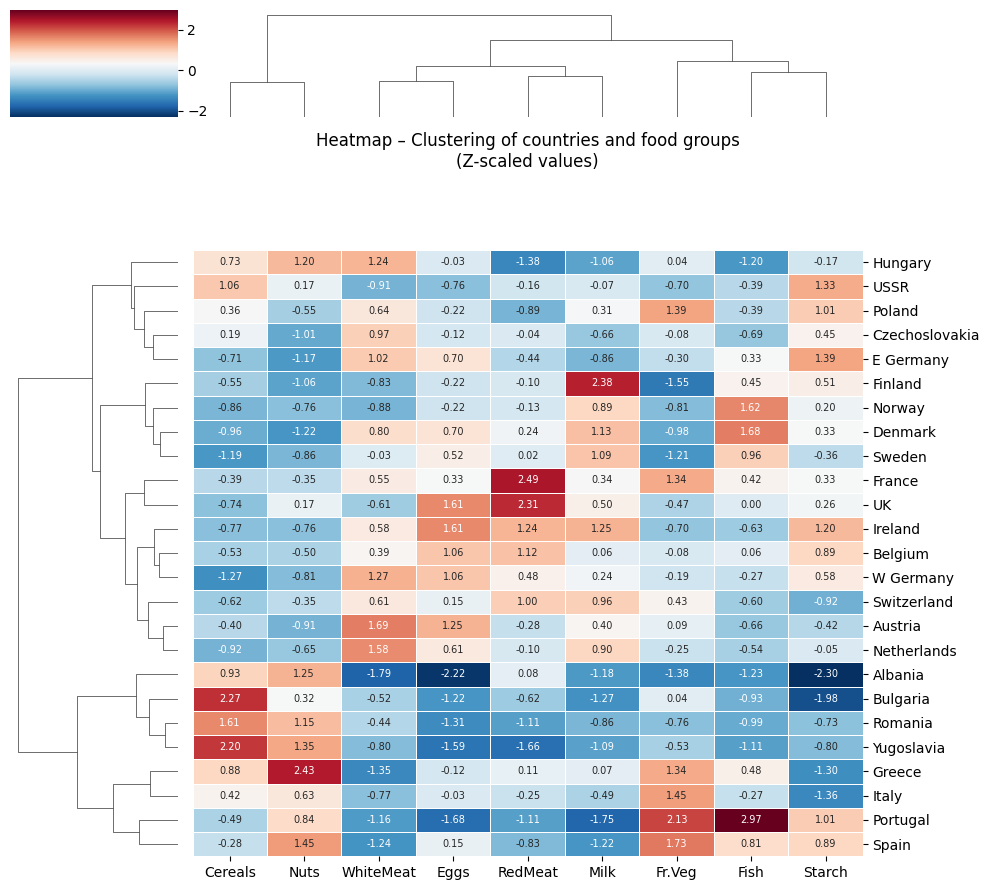

In [11]:
# Cluster map with scaled data
cmap = sns.clustermap(
    df_scaled,
    method='ward',
    metric='euclidean',
    cmap='RdBu_r',
    figsize=(10, 9),
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.4,
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=(0.2, 0.15)
)

cmap.ax_heatmap.set_title('Heatmap – Clustering of countries and food groups\n(Z-scaled values)',
                           fontsize=12, pad=60)
plt.tight_layout()
plt.show()

# **Task 7** Dichtebasiertes Clustering

In [14]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=1.8, min_samples=2)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'Number of clusters (without noise): {n_clusters}')
print(f'Number of outliers: {n_noise}')
print(f'\nLabel allocation:')
label_series = pd.Series(dbscan_labels, index=df.index)
print(label_series.value_counts().sort_index())

Number of clusters (without noise): 3
Number of outliers: 15

Label allocation:
-1    15
 0     5
 1     3
 2     2
Name: count, dtype: int64


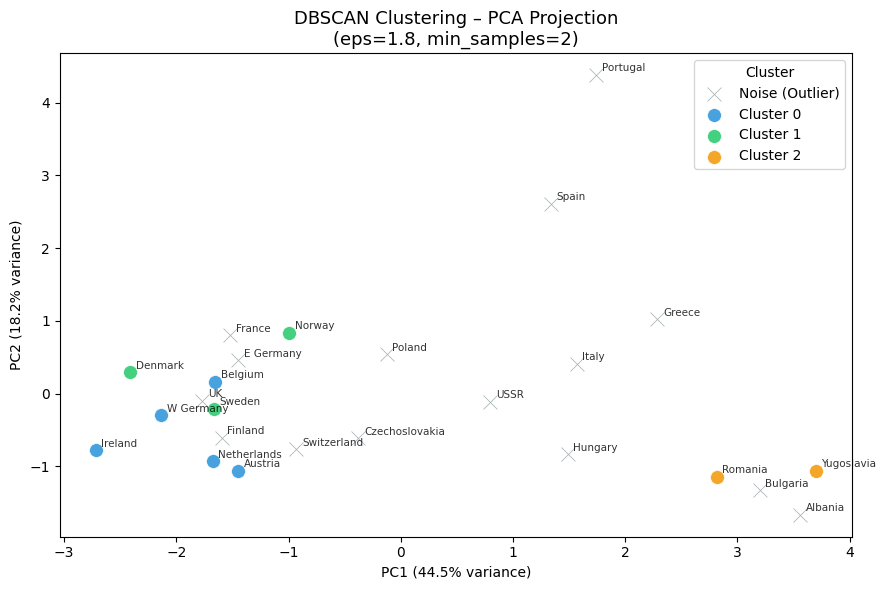

In [15]:
# Visualise DBSCAN results using PCA
unique_labels = sorted(set(dbscan_labels))
palette = ['#95a5a6' if l == -1 else colors[i % len(colors)]
           for i, l in enumerate(unique_labels)]

fig, ax = plt.subplots(figsize=(9, 6))

for i, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    name = 'Noise (Outlier)' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=palette[i], label=name, s=100,
               marker=marker, edgecolors='white', linewidths=0.5, alpha=0.9)

for i, country in enumerate(df.index):
    ax.annotate(country, (X_pca[i, 0] + 0.05, X_pca[i, 1] + 0.05),
                fontsize=7.5, alpha=0.8)

ax.set_title(f'DBSCAN Clustering – PCA Projection\n(eps=1.8, min_samples=2)', fontsize=13)
ax.set_xlabel(f'PC1 ({explained_var[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({explained_var[1]:.1%} variance)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

# **Task 8** Comparison of clustering methods

In [16]:
from scipy.cluster.hierarchy import fcluster

# Hierarchical clustering with best_k clusters
hier_labels = fcluster(Z, t=best_k, criterion='maxclust') - 1  # 0-indexed

# Comparison table
comparison = pd.DataFrame({
    'KMeans': cluster_labels,
    'Hierarchical': hier_labels,
    'DBSCAN': dbscan_labels
}, index=df.index)

print(f'Comparison of cluster classifications (k={best_k}):')
comparison

Comparison of cluster classifications (k=3):


,KMeans,Hierarchical,DBSCAN
Albania,2,1,-1
Austria,1,0,0
Belgium,1,0,0
Bulgaria,2,1,-1
Czechoslovakia,1,0,-1
Denmark,1,0,1
E Germany,1,0,-1
Finland,1,0,-1
France,1,0,-1
Greece,0,2,-1


In [17]:
# Compare silhouette scores (only for methods with more than one cluster)
score_kmeans = metrics.silhouette_score(X_scaled, cluster_labels)
score_hier   = metrics.silhouette_score(X_scaled, hier_labels)

print('A comparison of silhouette coefficients:')
print(f'  KMeans (k={best_k}):          {score_kmeans:.4f}')
print(f'  Hierarchical (k={best_k}):    {score_hier:.4f}')

if n_clusters > 1:
    # Exclude noise points from the DBSCAN score
    mask_no_noise = dbscan_labels != -1
    if mask_no_noise.sum() > 1:
        score_dbscan = metrics.silhouette_score(
            X_scaled[mask_no_noise], dbscan_labels[mask_no_noise])
        print(f'  DBSCAN (without noise):    {score_dbscan:.4f}')
    else:
        print('  DBSCAN: Not enough points for the silhouette score')
else:
    print('  DBSCAN: Only 1 cluster, silhouette score cannot be calculated')

A comparison of silhouette coefficients:
  KMeans (k=3):          0.3352
  Hierarchical (k=3):    0.3288
  DBSCAN (without noise):    0.4727
